fetching 20 OSM tiles at zoom 12 ...
querying Overpass (https://maps.mail.ru/osm/tools/overpass/api/interpreter) ...
OSM features:  highway=408  railway=26  landuse=1268  leisure=345  building=9434  amenity=404


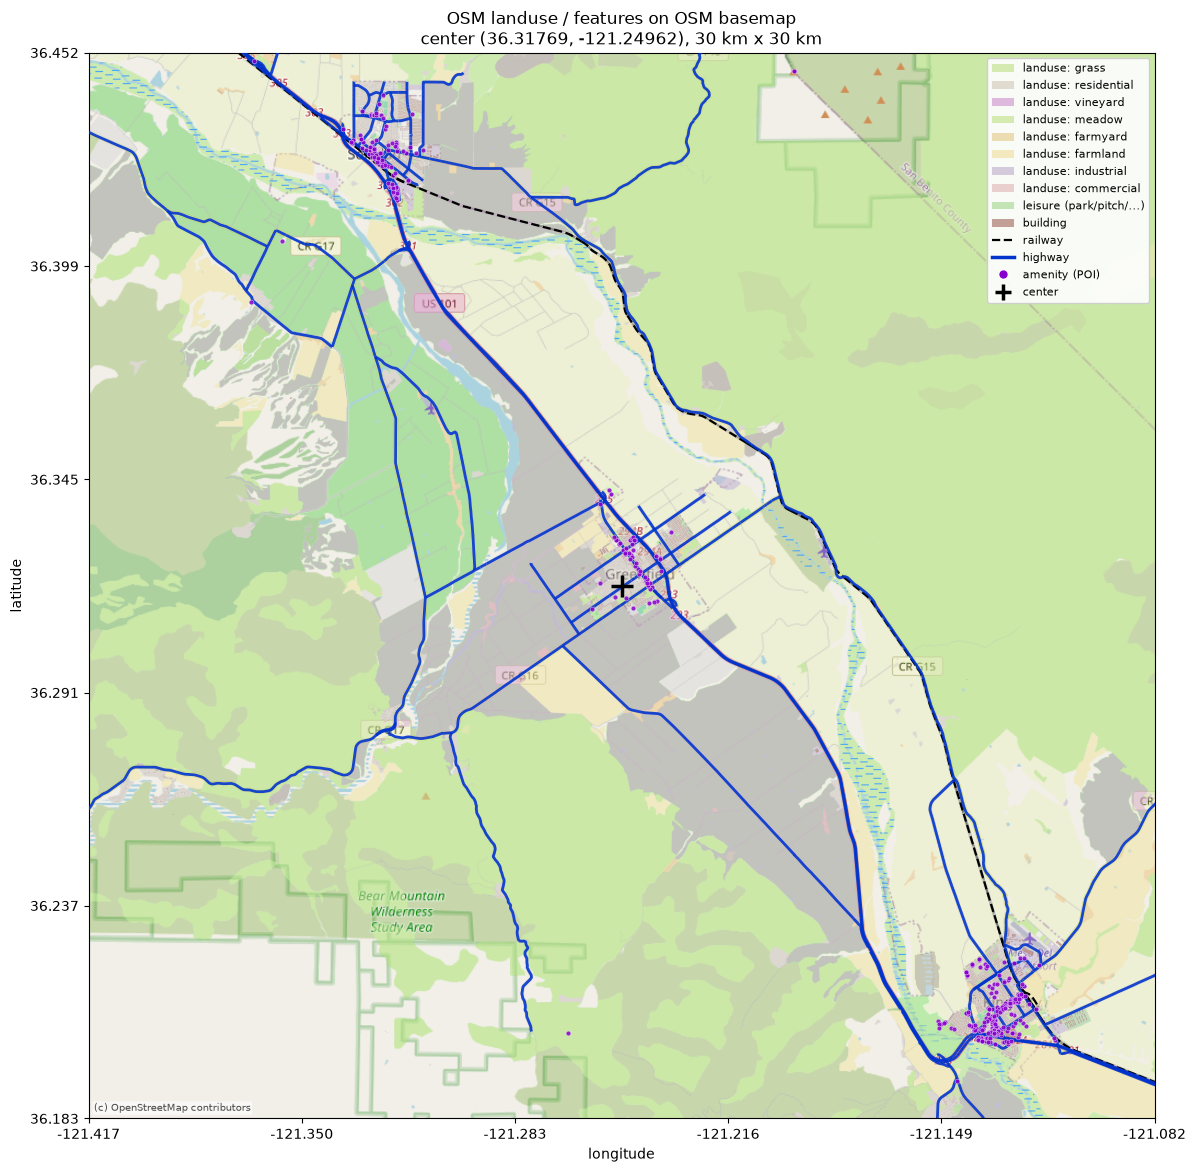

In [3]:
%matplotlib inline

import io
import json
import math
import sys
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

# ----------------------------------------------------------------------------
# Hardcoded configuration
# ----------------------------------------------------------------------------
CENTER_LAT = 36.31769
CENTER_LON = -121.24962
BOX_KM = 30.0    # full width/height of the (square) window in km
ZOOM = 12        # OSM tile zoom level

# which OSM feature layers to draw (no clustering/settlement boxes here)
OSM_LAYERS = {
    "landuse": True,
    "leisure": True,
    "building": True,
    "amenity": True,
    "railway": True,
    "highway": True,
}

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0   # Web Mercator sphere radius (m)
USER_AGENT = "countryside_map/1.0 (OSM landuse map demo)"
_HEADERS = {"User-Agent": USER_AGENT}  # OSM tile server / Overpass reject requests without one


def http_get(url, timeout=30):
    """GET a URL with urllib and return the raw response bytes."""
    req = urllib.request.Request(url, headers=_HEADERS, method="GET")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


def http_post_form(url, form, timeout=60):
    """POST a form-encoded body with urllib and return the raw response bytes."""
    body = urllib.parse.urlencode(form).encode("utf-8")
    req = urllib.request.Request(url, data=body, headers=_HEADERS, method="POST")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


LANDUSE_COLORS = {
    "farmland": "#f3e4b0", "farmyard": "#e8d5a0", "vineyard": "#d7a8d7",
    "orchard": "#c6df9a", "residential": "#dcd2c6", "commercial": "#e6c6c6",
    "retail": "#e6afaf", "industrial": "#cdbdd6", "forest": "#a6cf96",
    "meadow": "#cbe69f", "grass": "#cbe69f", "cemetery": "#b3c49f",
    "recreation_ground": "#c2df9f", "quarry": "#c6bfb0",
}
LANDUSE_DEFAULT = "#d9d9d9"
LEISURE_COLORS = {
    "park": "#b3e096", "garden": "#b3e096", "nature_reserve": "#a0d488",
    "pitch": "#9bd6ab", "playground": "#e0d3ad", "golf_course": "#aede96",
}
LEISURE_DEFAULT = "#b9dea6"
BUILDING_COLOR = "#b98f86"
AMENITY_COLOR = "#8800cc"


# ----------------------------------------------------------------------------
# Web Mercator helpers
# ----------------------------------------------------------------------------
def merc(lon, lat):
    x = _R * math.radians(lon)
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def merc_arr(lons, lats):
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(np.tan(np.pi / 4 + np.radians(lats) / 2))
    return x, y


def ring_to_merc(geometry):
    lons = [p["lon"] for p in geometry]
    lats = [p["lat"] for p in geometry]
    x, y = merc_arr(lons, lats)
    return np.column_stack([x, y])


def bbox_from_center(lat, lon, box_km):
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (_KM_PER_DEG_LAT * max(math.cos(math.radians(lat)), 1e-6))
    return lon - d_lon, lat - d_lat, lon + d_lon, lat + d_lat  # west, south, east, north


# ----------------------------------------------------------------------------
# OSM tile basemap
# ----------------------------------------------------------------------------
def _deg2num(lat, lon, n):
    x = (lon + 180.0) / 360.0 * n
    lat_r = math.radians(lat)
    y = (1.0 - math.asinh(math.tan(lat_r)) / math.pi) / 2.0 * n
    return x, y


def _num2lat(y, n):
    return math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * y / n))))


def fetch_osm_basemap(west, south, east, north, zoom):
    """Download & stitch OSM tiles. Returns (image_array, mercator_extent)."""
    n = 2 ** zoom
    x_tl, y_tl = _deg2num(north, west, n)
    x_br, y_br = _deg2num(south, east, n)
    tx0, tx1 = int(math.floor(x_tl)), int(math.floor(x_br))
    ty0, ty1 = int(math.floor(y_tl)), int(math.floor(y_br))

    n_tiles = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
    print(f"fetching {n_tiles} OSM tiles at zoom {zoom} ...")

    canvas = Image.new("RGB", ((tx1 - tx0 + 1) * 256, (ty1 - ty0 + 1) * 256), (221, 221, 221))
    subdomains = ["a", "b", "c"]
    for tx in range(tx0, tx1 + 1):
        for ty in range(ty0, ty1 + 1):
            sub = subdomains[(tx + ty) % 3]
            url = f"https://{sub}.tile.openstreetmap.org/{zoom}/{tx}/{ty}.png"
            try:
                content = http_get(url, timeout=30)
                tile = Image.open(io.BytesIO(content)).convert("RGB")
                canvas.paste(tile, ((tx - tx0) * 256, (ty - ty0) * 256))
            except Exception as exc:  # noqa: BLE001 - leave gray tile on failure
                print(f"  tile {zoom}/{tx}/{ty} failed: {exc}", file=sys.stderr)

    lon_left = tx0 / n * 360.0 - 180.0
    lon_right = (tx1 + 1) / n * 360.0 - 180.0
    lat_top = _num2lat(ty0, n)
    lat_bot = _num2lat(ty1 + 1, n)
    x_left, y_top = merc(lon_left, lat_top)
    x_right, y_bot = merc(lon_right, lat_bot)
    return np.asarray(canvas), (x_left, x_right, y_bot, y_top)


# ----------------------------------------------------------------------------
# OSM vector features (Overpass) — no clustering, just the raw geometries
# ----------------------------------------------------------------------------
def fetch_osm_features(west, south, east, north, want, timeout=120):
    feats = {k: [] for k in ("highway", "railway", "landuse", "leisure",
                             "building", "amenity")}
    bbox = f"{south},{west},{north},{east}"
    parts = []
    if want.get("highway"):
        parts.append(f'way["highway"~"^(motorway|trunk|primary|secondary|tertiary)$"]({bbox});')
    if want.get("railway"):
        parts.append(f'way["railway"~"^(rail|light_rail|tram|subway|narrow_gauge)$"]({bbox});')
    if want.get("landuse"):
        parts.append(f'way["landuse"]({bbox});')
    if want.get("leisure"):
        parts.append(f'way["leisure"]({bbox});')
    if want.get("building"):
        parts.append(f'way["building"]({bbox});')
    if want.get("amenity"):
        parts.append(f'node["amenity"]({bbox});')
        parts.append(f'way["amenity"]({bbox});')
    if not parts:
        return feats

    query = f"[out:json][timeout:{timeout}];\n(\n  " + "\n  ".join(parts) + "\n);\nout geom;"
    endpoints = [
        "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]
    data = None
    for url in endpoints:
        try:
            print(f"querying Overpass ({url}) ...")
            payload = http_post_form(url, {"data": query}, timeout=timeout + 30)
            data = json.loads(payload)
            break
        except Exception as exc:  # noqa: BLE001
            print(f"overpass {url} failed: {exc}", file=sys.stderr)
    if data is None:
        print("no OSM feature data retrieved", file=sys.stderr)
        return feats

    for el in data.get("elements", []):
        tags = el.get("tags", {})
        etype = el.get("type")
        if etype == "node" and "amenity" in tags:
            feats["amenity"].append((el["lon"], el["lat"], tags["amenity"]))
            continue
        if etype != "way" or "geometry" not in el:
            continue
        geom = el["geometry"]
        if "highway" in tags:
            feats["highway"].append((geom, tags.get("ref") or tags.get("name", "")))
        elif "railway" in tags:
            feats["railway"].append(geom)
        elif "building" in tags:
            feats["building"].append(geom)
        elif "landuse" in tags:
            feats["landuse"].append((geom, tags["landuse"]))
        elif "leisure" in tags:
            feats["leisure"].append((geom, tags["leisure"]))
        elif "amenity" in tags:
            lons = [p["lon"] for p in geom]
            lats = [p["lat"] for p in geom]
            feats["amenity"].append((sum(lons) / len(lons), sum(lats) / len(lats),
                                     tags["amenity"]))
    return feats


# ----------------------------------------------------------------------------
# Rendering helpers
# ----------------------------------------------------------------------------
def add_polygons(ax, items, color_of, zorder, alpha, edgecolor="none", lw=0.0):
    patches, facecolors = [], []
    for it in items:
        geom, value = it if isinstance(it, tuple) else (it, None)
        if len(geom) < 3:
            continue
        patches.append(MplPolygon(ring_to_merc(geom), closed=True))
        facecolors.append(color_of(value))
    if not patches:
        return
    ax.add_collection(PatchCollection(patches, facecolors=facecolors,
                                      edgecolors=edgecolor, linewidths=lw,
                                      alpha=alpha, zorder=zorder))


def setup_axes(ax, base_img, base_extent, west, south, east, north, title):
    ax.imshow(base_img, extent=base_extent, origin="upper", interpolation="bilinear",
              zorder=0)
    xw, yb = merc(west, south)
    xe, yt = merc(east, north)
    ax.set_xlim(xw, xe)
    ax.set_ylim(yb, yt)
    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)
    ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
    ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
    ax.set_yticklabels([f"{v:.3f}" for v in lat_ticks])
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    return (xw, yb, xe, yt)


def add_attribution(ax):
    ax.text(0.005, 0.005, "(c) OpenStreetMap contributors", transform=ax.transAxes,
            fontsize=7, color="black", alpha=0.7, ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))


# ----------------------------------------------------------------------------
# Fetch inputs and draw the landuse / feature map (no clustering)
# ----------------------------------------------------------------------------
west, south, east, north = bbox_from_center(CENTER_LAT, CENTER_LON, BOX_KM)
base_img, base_extent = fetch_osm_basemap(west, south, east, north, ZOOM)
feats = fetch_osm_features(west, south, east, north, OSM_LAYERS)
print("OSM features:  " + "  ".join(f"{k}={len(v)}" for k, v in feats.items()))

fig, ax = plt.subplots(figsize=(12, 12))
setup_axes(ax, base_img, base_extent, west, south, east, north,
           f"OSM landuse / features on OSM basemap\n"
           f"center ({CENTER_LAT}, {CENTER_LON}), {BOX_KM:.0f} km x {BOX_KM:.0f} km")
handles = []

if OSM_LAYERS["landuse"] and feats["landuse"]:
    add_polygons(ax, feats["landuse"],
                 lambda v: LANDUSE_COLORS.get(v, LANDUSE_DEFAULT),
                 zorder=1, alpha=0.5)
    counts = {}
    for _, v in feats["landuse"]:
        counts[v] = counts.get(v, 0) + 1
    for v, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:8]:
        handles.append(Patch(facecolor=LANDUSE_COLORS.get(v, LANDUSE_DEFAULT),
                             edgecolor="none", alpha=0.8, label=f"landuse: {v}"))

if OSM_LAYERS["leisure"] and feats["leisure"]:
    add_polygons(ax, feats["leisure"],
                 lambda v: LEISURE_COLORS.get(v, LEISURE_DEFAULT),
                 zorder=1.3, alpha=0.6)
    handles.append(Patch(facecolor=LEISURE_DEFAULT, edgecolor="none",
                         alpha=0.8, label="leisure (park/pitch/...)"))

if OSM_LAYERS["building"] and feats["building"]:
    add_polygons(ax, feats["building"], lambda v: BUILDING_COLOR,
                 zorder=2, alpha=0.8)
    handles.append(Patch(facecolor=BUILDING_COLOR, edgecolor="none",
                         alpha=0.85, label="building"))

if OSM_LAYERS["railway"] and feats["railway"]:
    segs = [ring_to_merc(g) for g in feats["railway"] if len(g) >= 2]
    ax.add_collection(LineCollection(segs, colors="black", linewidths=1.6,
                                     linestyles="dashed", zorder=3))
    handles.append(plt.Line2D([], [], color="black", lw=1.6, ls="dashed",
                              label="railway"))

if OSM_LAYERS["highway"] and feats["highway"]:
    segs = [ring_to_merc(g) for g, _ in feats["highway"] if len(g) >= 2]
    ax.add_collection(LineCollection(segs, colors="#0033cc", linewidths=2.0,
                                     alpha=0.9, zorder=3.5))
    handles.append(plt.Line2D([], [], color="#0033cc", lw=2.5, label="highway"))

if OSM_LAYERS["amenity"] and feats["amenity"]:
    alon = np.array([a[0] for a in feats["amenity"]])
    alat = np.array([a[1] for a in feats["amenity"]])
    axm, aym = merc_arr(alon, alat)
    ax.scatter(axm, aym, s=12, c=AMENITY_COLOR, marker="o", alpha=0.85,
               edgecolors="white", linewidths=0.3, zorder=4)
    handles.append(plt.Line2D([], [], color=AMENITY_COLOR, marker="o", ls="none",
                              ms=7, mec="white", label="amenity (POI)"))

ccx, ccy = merc(CENTER_LON, CENTER_LAT)
ax.plot([ccx], [ccy], marker="+", ms=16, mew=2.5, color="black", zorder=6)
handles.append(plt.Line2D([], [], marker="+", color="black", ls="none",
                          ms=12, mew=2.5, label="center"))
ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
add_attribution(ax)
fig.tight_layout()
plt.show()


fetching 20 OSM tiles at zoom 12 ...
dense threshold = 50.0 persons/km^2, 5 cluster(s):
  cluster #1: 15 cells, peak 5196 persons/km^2, lat [36.31494, 36.33994]  lon [-121.27102, -121.22935]
  cluster #2: 14 cells, peak 3753 persons/km^2, lat [36.42327, 36.44827]  lon [-121.33769, -121.30435]
  cluster #3: 13 cells, peak 4478 persons/km^2, lat [36.19827, 36.22327]  lon [-121.14602, -121.11269]
  cluster #4: 2 cells, peak 89 persons/km^2, lat [36.26494, 36.27327]  lon [-121.17935, -121.17935]
  cluster #5: 2 cells, peak 825 persons/km^2, lat [36.18994, 36.18994]  lon [-121.15435, -121.14602]


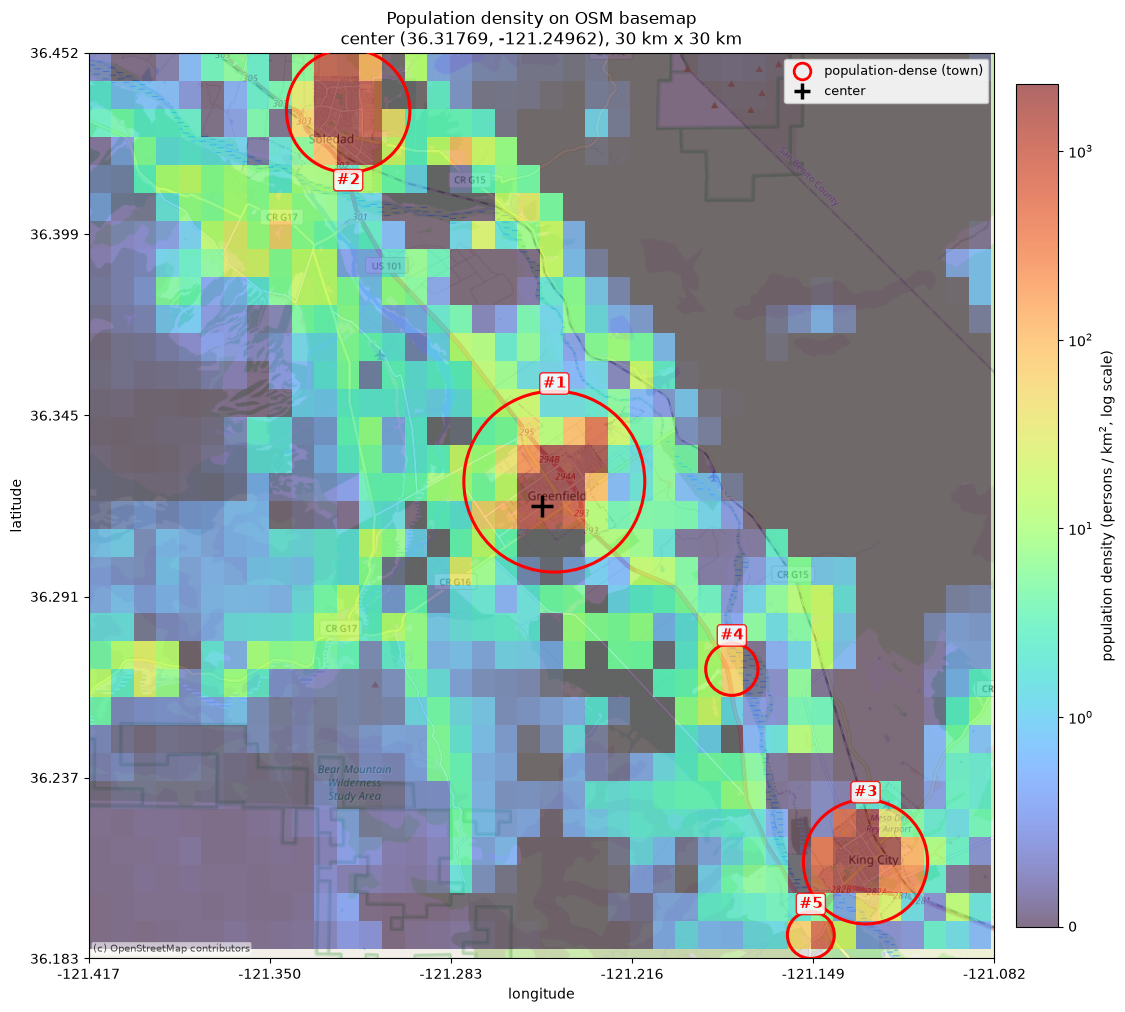

In [1]:
%matplotlib inline

import io
import math
import sys
import urllib.request
from collections import deque

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.patches import Circle
from PIL import Image
from rasterio.windows import from_bounds

# ----------------------------------------------------------------------------
# Inputs
# ----------------------------------------------------------------------------
CENTER_LAT = 36.31769
CENTER_LON = -121.24962
BOX_KM = 30.0                     # full width/height of the (square) window in km
TIF_PATH = "usa_pd_2018_1km.tif"  # population-density raster (persons / km^2)

ZOOM = 12               # OSM tile zoom level for the basemap under the heatmap
DENSE_FLOOR = 50.0      # a cell counts as "populated" at >= this many persons/km^2
MIN_CLUSTER_CELLS = 2   # ignore population blobs smaller than this many cells

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0   # Web Mercator sphere radius (m)
USER_AGENT = "countryside_map/1.0 (population density map demo)"
_HEADERS = {"User-Agent": USER_AGENT}  # OSM tile server rejects requests without one


def http_get(url, timeout=30):
    """GET a URL with urllib and return the raw response bytes."""
    req = urllib.request.Request(url, headers=_HEADERS, method="GET")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


# ----------------------------------------------------------------------------
# Web Mercator helpers
# ----------------------------------------------------------------------------
def merc(lon, lat):
    x = _R * math.radians(lon)
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def merc_arr(lons, lats):
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(np.tan(np.pi / 4 + np.radians(lats) / 2))
    return x, y


def bbox_from_center(lat, lon, box_km):
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (_KM_PER_DEG_LAT * max(math.cos(math.radians(lat)), 1e-6))
    return lon - d_lon, lat - d_lat, lon + d_lon, lat + d_lat  # west, south, east, north


# ----------------------------------------------------------------------------
# OSM tile basemap
# ----------------------------------------------------------------------------
def _deg2num(lat, lon, n):
    x = (lon + 180.0) / 360.0 * n
    lat_r = math.radians(lat)
    y = (1.0 - math.asinh(math.tan(lat_r)) / math.pi) / 2.0 * n
    return x, y


def _num2lat(y, n):
    return math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * y / n))))


def fetch_osm_basemap(west, south, east, north, zoom):
    """Download & stitch OSM tiles. Returns (image_array, mercator_extent)."""
    n = 2 ** zoom
    x_tl, y_tl = _deg2num(north, west, n)
    x_br, y_br = _deg2num(south, east, n)
    tx0, tx1 = int(math.floor(x_tl)), int(math.floor(x_br))
    ty0, ty1 = int(math.floor(y_tl)), int(math.floor(y_br))

    n_tiles = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
    print(f"fetching {n_tiles} OSM tiles at zoom {zoom} ...")

    canvas = Image.new("RGB", ((tx1 - tx0 + 1) * 256, (ty1 - ty0 + 1) * 256), (221, 221, 221))
    subdomains = ["a", "b", "c"]
    for tx in range(tx0, tx1 + 1):
        for ty in range(ty0, ty1 + 1):
            sub = subdomains[(tx + ty) % 3]
            url = f"https://{sub}.tile.openstreetmap.org/{zoom}/{tx}/{ty}.png"
            try:
                content = http_get(url, timeout=30)
                tile = Image.open(io.BytesIO(content)).convert("RGB")
                canvas.paste(tile, ((tx - tx0) * 256, (ty - ty0) * 256))
            except Exception as exc:  # noqa: BLE001 - leave gray tile on failure
                print(f"  tile {zoom}/{tx}/{ty} failed: {exc}", file=sys.stderr)

    lon_left = tx0 / n * 360.0 - 180.0
    lon_right = (tx1 + 1) / n * 360.0 - 180.0
    lat_top = _num2lat(ty0, n)
    lat_bot = _num2lat(ty1 + 1, n)
    x_left, y_top = merc(lon_left, lat_top)
    x_right, y_bot = merc(lon_right, lat_bot)
    return np.asarray(canvas), (x_left, x_right, y_bot, y_top)


# ----------------------------------------------------------------------------
# Population density raster
# ----------------------------------------------------------------------------
def read_pop_window(tif_path, west, south, east, north):
    with rasterio.open(tif_path) as ds:
        b = ds.bounds
        window = from_bounds(max(west, b.left), max(south, b.bottom),
                             min(east, b.right), min(north, b.top),
                             transform=ds.transform)
        data = ds.read(1, window=window).astype("float32")
        tr = ds.window_transform(window)
        nodata = ds.nodata
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data < 0, np.nan, data)
    return data, tr


def cell_centers(data, transform):
    ny, nx = data.shape
    cols, rows = np.meshgrid(np.arange(nx), np.arange(ny))
    lon = transform.c + transform.a * (cols + 0.5) + transform.b * (rows + 0.5)
    lat = transform.f + transform.d * (cols + 0.5) + transform.e * (rows + 0.5)
    return lon, lat


def cell_edges_merc(data, transform):
    ny, nx = data.shape
    cols, rows = np.meshgrid(np.arange(nx + 1), np.arange(ny + 1))
    lon = transform.c + transform.a * cols + transform.b * rows
    lat = transform.f + transform.d * cols + transform.e * rows
    return merc_arr(lon, lat)


def connected_components(mask):
    """4-connected labeling of a boolean mask. Returns list of [(r,c), ...] blobs."""
    ny, nx = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    blobs = []
    for r in range(ny):
        for c in range(nx):
            if mask[r, c] and not seen[r, c]:
                q = deque([(r, c)])
                seen[r, c] = True
                cells = []
                while q:
                    cr, cc = q.popleft()
                    cells.append((cr, cc))
                    for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        nr, nc = cr + dr, cc + dc
                        if 0 <= nr < ny and 0 <= nc < nx and mask[nr, nc] and not seen[nr, nc]:
                            seen[nr, nc] = True
                            q.append((nr, nc))
                blobs.append(cells)
    return blobs


# ----------------------------------------------------------------------------
# Rendering helpers
# ----------------------------------------------------------------------------
def setup_axes(ax, base_img, base_extent, west, south, east, north, title):
    ax.imshow(base_img, extent=base_extent, origin="upper", interpolation="bilinear",
              zorder=0)
    xw, yb = merc(west, south)
    xe, yt = merc(east, north)
    ax.set_xlim(xw, xe)
    ax.set_ylim(yb, yt)
    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)
    ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
    ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
    ax.set_yticklabels([f"{v:.3f}" for v in lat_ticks])
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    return (xw, yb, xe, yt)


def add_attribution(ax):
    ax.text(0.005, 0.005, "(c) OpenStreetMap contributors", transform=ax.transAxes,
            fontsize=7, color="black", alpha=0.7, ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))


# ----------------------------------------------------------------------------
# Fetch inputs and draw the population-density map
# ----------------------------------------------------------------------------
west, south, east, north = bbox_from_center(CENTER_LAT, CENTER_LON, BOX_KM)
base_img, base_extent = fetch_osm_basemap(west, south, east, north, ZOOM)
data, transform = read_pop_window(TIF_PATH, west, south, east, north)

lon2d, lat2d = cell_centers(data, transform)
valid = data[np.isfinite(data)]
thresh = max(np.nanpercentile(valid, 90), DENSE_FLOOR)
dense_mask = np.isfinite(data) & (data >= thresh)
blobs = [b for b in connected_components(dense_mask) if len(b) >= MIN_CLUSTER_CELLS]
print(f"dense threshold = {thresh:.1f} persons/km^2, {len(blobs)} cluster(s):")

fig, ax = plt.subplots(figsize=(12, 12))
_, yb, _, yt = setup_axes(ax, base_img, base_extent, west, south, east, north,
                          f"Population density on OSM basemap\n"
                          f"center ({CENTER_LAT}, {CENTER_LON}), "
                          f"{BOX_KM:.0f} km x {BOX_KM:.0f} km")

Xe, Ye = cell_edges_merc(data, transform)
masked = np.ma.masked_invalid(data)
vmax = max(float(np.nanpercentile(valid, 99)), 1.0)
norm = matplotlib.colors.SymLogNorm(linthresh=1.0, vmin=0.0, vmax=vmax)
cmap = plt.get_cmap("turbo").copy()
cmap.set_bad(alpha=0.0)
mesh = ax.pcolormesh(Xe, Ye, masked, cmap=cmap, norm=norm, alpha=0.6,
                     shading="flat", zorder=2)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("population density (persons / km$^2$, log scale)")

for i, cells in enumerate(sorted(blobs, key=len, reverse=True), 1):
    rows = [c[0] for c in cells]
    cols = [c[1] for c in cells]
    clons = lon2d[rows, cols]
    clats = lat2d[rows, cols]
    vals = data[rows, cols]
    cx, cy = merc(clons.mean(), clats.mean())
    mx, my = merc_arr(clons, clats)
    radius = max(np.hypot(mx - cx, my - cy).max(), 400.0) + 500.0
    ax.add_patch(Circle((cx, cy), radius, fill=False, edgecolor="red",
                        linewidth=2.2, zorder=5))
    if cy + radius > yt - (yt - yb) * 0.06:
        ly, va = cy - radius, "top"
    else:
        ly, va = cy + radius, "bottom"
    ax.text(cx, ly, f"#{i}", color="red", fontsize=11, fontweight="bold",
            ha="center", va=va, zorder=6,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.85))
    print(f"  cluster #{i}: {len(cells)} cells, peak {vals.max():.0f} persons/km^2, "
          f"lat [{clats.min():.5f}, {clats.max():.5f}]  "
          f"lon [{clons.min():.5f}, {clons.max():.5f}]")

ccx, ccy = merc(CENTER_LON, CENTER_LAT)
ax.plot([ccx], [ccy], marker="+", ms=16, mew=2.5, color="black", zorder=6)
handles = [
    plt.Line2D([], [], marker="o", mfc="none", mec="red", mew=2, ls="none",
               ms=12, label="population-dense (town)"),
    plt.Line2D([], [], marker="+", color="black", ls="none", ms=12, mew=2.5,
               label="center"),
]
ax.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
add_attribution(ax)
fig.tight_layout()
plt.show()


fetching 20 OSM tiles at zoom 12 ...
querying Overpass (https://maps.mail.ru/osm/tools/overpass/api/interpreter) ...
OSM features: highway=408  railway=26  landuse=1269  leisure=348  building=9434  amenity=499
selected region area: 16.559 km^2
downsampled coordinates: 250
outputs written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output
first 10 coordinates:
point_id  latitude   longitude    source  distance_to_center_m  circle_radius_m
   P0001 36.317690 -121.249620    center              0.000000             10.0
   P0002 36.316512 -121.251161   highway            190.332324             10.0
   P0003 36.318388 -121.247654 area_grid            192.748628             10.0
   P0004 36.320360 -121.249003 area_grid            301.358301             10.0
   P0005 36.318470 -121.253222 area_grid            334.805253             10.0
   P0006 36.320400 -121.251787 area_grid            358.173265             10.0
   P0007 36.314527 -121.250525 area_grid            360.229057    

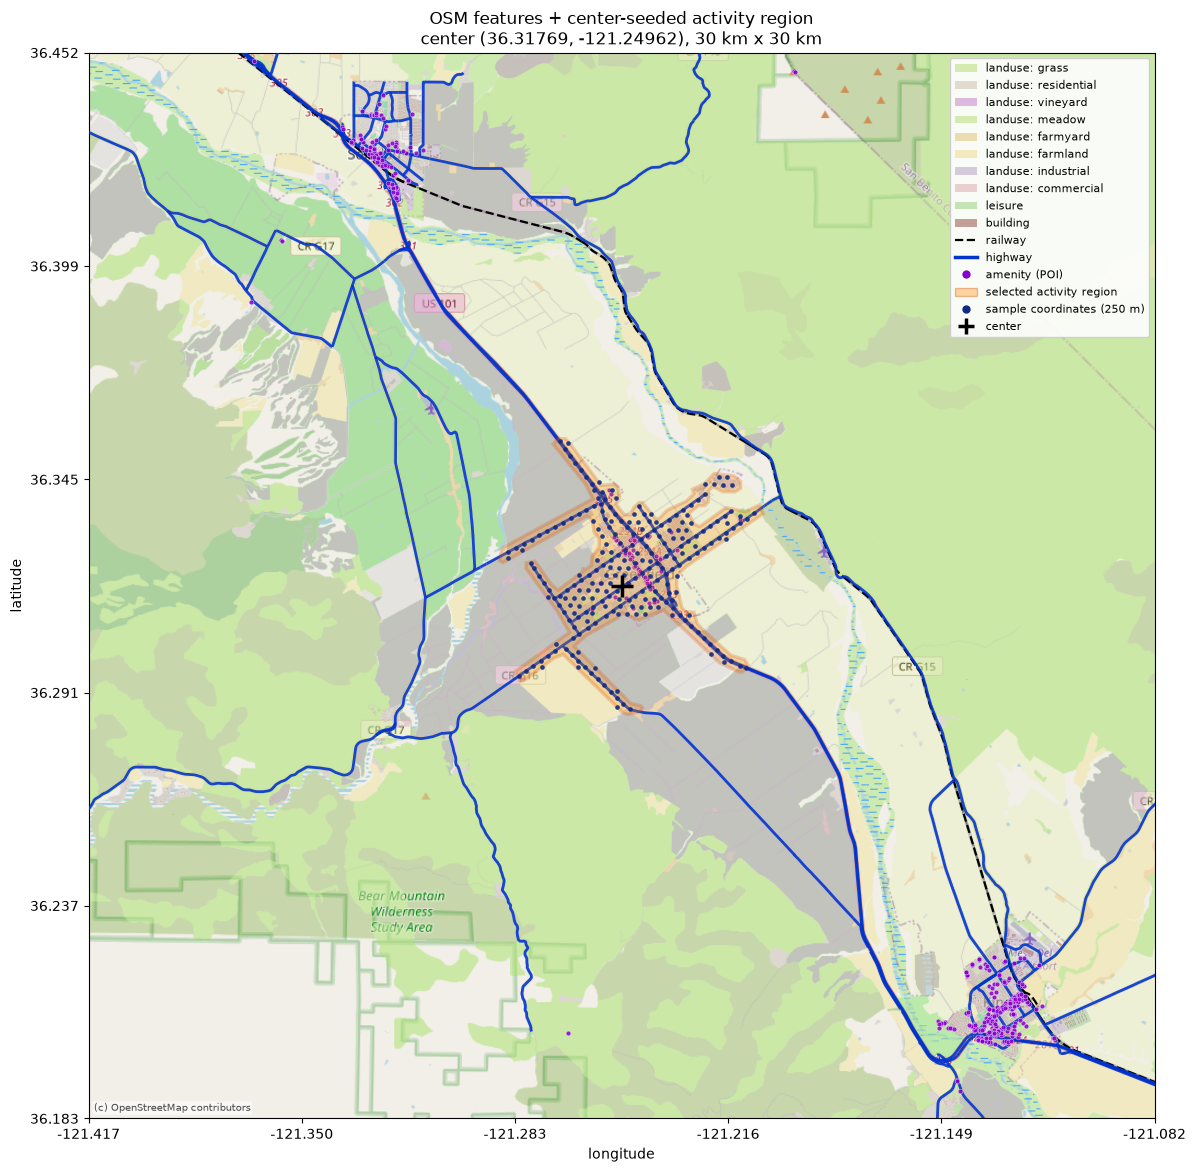

figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/activity_region_and_samples.png
coordinate_list variable is ready; length=250


In [3]:
"""
Center-seeded OSM activity-region clustering.

This is a revised version of the user's original OSM plotting code. It:

1. downloads the same raw OSM features with Overpass;
2. computes the cluster from OSM tags and geometries, not from plot colors;
3. keeps the residential/amenity/building core near the center;
4. allows locally connected highway branches to extend from that core;
5. outputs the selected region as GeoJSON;
6. outputs downsampled coordinates as CSV and JSON;
7. outputs a 10 m circle around each sampled coordinate as GeoJSON;
8. plots the OSM layers, selected region, and sampled coordinates together.

Required third-party packages:
    numpy matplotlib pillow scipy shapely rasterio pyproj pandas

Install when needed:
    pip install numpy matplotlib pillow scipy shapely rasterio pyproj pandas
"""

from __future__ import annotations

import io
import json
import math
import sys
import urllib.parse
import urllib.request
from pathlib import Path
from typing import Iterable, Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image
from pyproj import CRS, Transformer
from rasterio.features import rasterize, shapes
from rasterio.transform import from_origin
from scipy import ndimage as ndi
from shapely.geometry import (
    GeometryCollection,
    LineString,
    MultiLineString,
    MultiPolygon,
    Point,
    Polygon,
    mapping,
    shape,
)
from shapely.ops import transform as shapely_transform

try:
    from shapely import make_valid
except ImportError:
    def make_valid(geometry):
        return geometry.buffer(0)


# ============================================================================
# Configuration
# ============================================================================

CENTER_LAT = 36.31769
CENTER_LON = -121.24962

# Full map window. This is only the displayed/fetched window.
BOX_KM = 30.0
ZOOM = 12

OSM_LAYERS = {
    "landuse": True,
    "leisure": True,
    "building": True,
    "amenity": True,
    "railway": True,
    "highway": True,
}

# ------------------------- clustering parameters -----------------------------

# The selected cluster is not allowed to expand farther than this from center.
MAX_REGION_RADIUS_M = 4500.0

# Raster cell size used internally by the clustering algorithm.
# 40-75 m is usually a sensible range.
GRID_SIZE_M = 50.0

# Activity-score thresholds.
# HIGH_THRESHOLD creates the reliable activity core.
# LOW_THRESHOLD allows weaker evidence to connect to the core.
HIGH_THRESHOLD = 1.65
LOW_THRESHOLD = 0.30

# Highway corridor settings.
# Increasing these includes more highway corners/branches.
HIGHWAY_BUFFER_M = 120.0
HIGHWAY_MAX_EXTENSION_FROM_CORE_M = 2800.0
CORE_TO_HIGHWAY_BRIDGE_M = 200.0

# Boundary cleanup.
MORPHOLOGY_CLOSE_M = 100.0
POLYGON_SMOOTH_M = 50.0

# Coordinate downsampling.
SAMPLE_SPACING_M = 250.0
MIN_SAMPLE_SEPARATION_M = SAMPLE_SPACING_M * 0.65
CIRCLE_RADIUS_M = 10.0

OUTPUT_DIR = Path("osm_activity_output")

# Land-use categories used as evidence.
POSITIVE_LANDUSE = {
    "residential",
    "commercial",
    "retail",
    "industrial",
    "education",
    "institutional",
}

LOW_ACTIVITY_LANDUSE = {
    "farmland",
    "farmyard",
    "vineyard",
    "orchard",
    "forest",
    "meadow",
    "grass",
    "quarry",
}

POSITIVE_LEISURE = {
    "park",
    "garden",
    "pitch",
    "playground",
    "sports_centre",
    "recreation_ground",
}

# Activity-score weights. These are independent of plot colors.
WEIGHT_RESIDENTIAL = 3.0
WEIGHT_AMENITY = 4.0
WEIGHT_BUILDING = 1.2
WEIGHT_LEISURE = 0.6
WEIGHT_LOW_ACTIVITY = -0.8
WEIGHT_DISTANCE = -0.7


# ============================================================================
# Original network and plotting configuration
# ============================================================================

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0
USER_AGENT = "countryside_map/1.1 (OSM activity-region clustering)"
_HEADERS = {"User-Agent": USER_AGENT}

LANDUSE_COLORS = {
    "farmland": "#f3e4b0",
    "farmyard": "#e8d5a0",
    "vineyard": "#d7a8d7",
    "orchard": "#c6df9a",
    "residential": "#dcd2c6",
    "commercial": "#e6c6c6",
    "retail": "#e6afaf",
    "industrial": "#cdbdd6",
    "forest": "#a6cf96",
    "meadow": "#cbe69f",
    "grass": "#cbe69f",
    "cemetery": "#b3c49f",
    "recreation_ground": "#c2df9f",
    "quarry": "#c6bfb0",
}
LANDUSE_DEFAULT = "#d9d9d9"

LEISURE_COLORS = {
    "park": "#b3e096",
    "garden": "#b3e096",
    "nature_reserve": "#a0d488",
    "pitch": "#9bd6ab",
    "playground": "#e0d3ad",
    "golf_course": "#aede96",
}
LEISURE_DEFAULT = "#b9dea6"
BUILDING_COLOR = "#b98f86"
AMENITY_COLOR = "#8800cc"
HIGHWAY_COLOR = "#0033cc"
REGION_FACE_COLOR = "#ff8c00"
REGION_EDGE_COLOR = "#d94801"
SAMPLE_POINT_COLOR = "#102a83"


# ============================================================================
# HTTP helpers
# ============================================================================

def http_get(url: str, timeout: int = 30) -> bytes:
    req = urllib.request.Request(url, headers=_HEADERS, method="GET")
    with urllib.request.urlopen(req, timeout=timeout) as response:
        return response.read()


def http_post_form(url: str, form: dict, timeout: int = 60) -> bytes:
    body = urllib.parse.urlencode(form).encode("utf-8")
    req = urllib.request.Request(
        url,
        data=body,
        headers=_HEADERS,
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=timeout) as response:
        return response.read()


# ============================================================================
# Coordinate helpers
# ============================================================================

def merc(lon: float, lat: float) -> tuple[float, float]:
    x = _R * math.radians(lon)
    y = _R * math.log(
        math.tan(math.pi / 4 + math.radians(lat) / 2)
    )
    return x, y


def merc_arr(lons, lats) -> tuple[np.ndarray, np.ndarray]:
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(
        np.tan(math.pi / 4 + np.radians(lats) / 2)
    )
    return x, y


def ring_to_merc(geometry: list[dict]) -> np.ndarray:
    lons = [point["lon"] for point in geometry]
    lats = [point["lat"] for point in geometry]
    x, y = merc_arr(lons, lats)
    return np.column_stack([x, y])


def bbox_from_center(
    lat: float,
    lon: float,
    box_km: float,
) -> tuple[float, float, float, float]:
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (
        _KM_PER_DEG_LAT
        * max(math.cos(math.radians(lat)), 1e-6)
    )
    return (
        lon - d_lon,
        lat - d_lat,
        lon + d_lon,
        lat + d_lat,
    )


def choose_local_utm(lat: float, lon: float) -> CRS:
    zone = int((lon + 180.0) // 6.0) + 1
    epsg = (32600 if lat >= 0 else 32700) + zone
    return CRS.from_epsg(epsg)


# ============================================================================
# OSM tile basemap
# ============================================================================

def _deg2num(lat: float, lon: float, n: int) -> tuple[float, float]:
    x = (lon + 180.0) / 360.0 * n
    lat_r = math.radians(lat)
    y = (
        1.0
        - math.asinh(math.tan(lat_r)) / math.pi
    ) / 2.0 * n
    return x, y


def _num2lat(y: float, n: int) -> float:
    return math.degrees(
        math.atan(
            math.sinh(math.pi * (1.0 - 2.0 * y / n))
        )
    )


def fetch_osm_basemap(
    west: float,
    south: float,
    east: float,
    north: float,
    zoom: int,
):
    n = 2 ** zoom
    x_tl, y_tl = _deg2num(north, west, n)
    x_br, y_br = _deg2num(south, east, n)

    tx0, tx1 = int(math.floor(x_tl)), int(math.floor(x_br))
    ty0, ty1 = int(math.floor(y_tl)), int(math.floor(y_br))

    n_tiles = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
    print(f"fetching {n_tiles} OSM tiles at zoom {zoom} ...")

    canvas = Image.new(
        "RGB",
        (
            (tx1 - tx0 + 1) * 256,
            (ty1 - ty0 + 1) * 256,
        ),
        (221, 221, 221),
    )

    subdomains = ["a", "b", "c"]
    for tx in range(tx0, tx1 + 1):
        for ty in range(ty0, ty1 + 1):
            subdomain = subdomains[(tx + ty) % 3]
            url = (
                f"https://{subdomain}.tile.openstreetmap.org/"
                f"{zoom}/{tx}/{ty}.png"
            )
            try:
                content = http_get(url, timeout=30)
                tile = Image.open(
                    io.BytesIO(content)
                ).convert("RGB")
                canvas.paste(
                    tile,
                    (
                        (tx - tx0) * 256,
                        (ty - ty0) * 256,
                    ),
                )
            except Exception as exc:
                print(
                    f"tile {zoom}/{tx}/{ty} failed: {exc}",
                    file=sys.stderr,
                )

    lon_left = tx0 / n * 360.0 - 180.0
    lon_right = (tx1 + 1) / n * 360.0 - 180.0
    lat_top = _num2lat(ty0, n)
    lat_bottom = _num2lat(ty1 + 1, n)

    x_left, y_top = merc(lon_left, lat_top)
    x_right, y_bottom = merc(lon_right, lat_bottom)

    return (
        np.asarray(canvas),
        (x_left, x_right, y_bottom, y_top),
    )


# ============================================================================
# OSM vector features
# ============================================================================

def fetch_osm_features(
    west: float,
    south: float,
    east: float,
    north: float,
    want: dict,
    timeout: int = 120,
) -> dict:
    feats = {
        key: []
        for key in (
            "highway",
            "railway",
            "landuse",
            "leisure",
            "building",
            "amenity",
        )
    }

    bbox = f"{south},{west},{north},{east}"
    parts = []

    if want.get("highway"):
        parts.append(
            'way["highway"~"^(motorway|trunk|primary|secondary|tertiary)$"]'
            f"({bbox});"
        )
    if want.get("railway"):
        parts.append(
            'way["railway"~"^(rail|light_rail|tram|subway|narrow_gauge)$"]'
            f"({bbox});"
        )
    if want.get("landuse"):
        parts.append(f'way["landuse"]({bbox});')
    if want.get("leisure"):
        parts.append(f'way["leisure"]({bbox});')
    if want.get("building"):
        parts.append(f'way["building"]({bbox});')
    if want.get("amenity"):
        parts.append(f'node["amenity"]({bbox});')
        parts.append(f'way["amenity"]({bbox});')

    if not parts:
        return feats

    query = (
        f"[out:json][timeout:{timeout}];\n"
        "(\n  "
        + "\n  ".join(parts)
        + "\n);\nout geom;"
    )

    endpoints = [
        "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]

    data = None
    for url in endpoints:
        try:
            print(f"querying Overpass ({url}) ...")
            payload = http_post_form(
                url,
                {"data": query},
                timeout=timeout + 30,
            )
            data = json.loads(payload)
            break
        except Exception as exc:
            print(
                f"overpass {url} failed: {exc}",
                file=sys.stderr,
            )

    if data is None:
        raise RuntimeError("No OSM feature data were retrieved.")

    for element in data.get("elements", []):
        tags = element.get("tags", {})
        element_type = element.get("type")

        if element_type == "node":
            if "amenity" in tags:
                feats["amenity"].append(
                    (
                        element["lon"],
                        element["lat"],
                        tags["amenity"],
                    )
                )
            continue

        if element_type != "way" or "geometry" not in element:
            continue

        geometry = element["geometry"]

        # These are independent if-statements rather than elif-statements.
        # One OSM way may legitimately belong to more than one layer.
        if "highway" in tags:
            feats["highway"].append(
                (
                    geometry,
                    tags.get("ref")
                    or tags.get("name", ""),
                )
            )

        if "railway" in tags:
            feats["railway"].append(geometry)

        if "building" in tags:
            feats["building"].append(geometry)

        if "landuse" in tags:
            feats["landuse"].append(
                (geometry, tags["landuse"])
            )

        if "leisure" in tags:
            feats["leisure"].append(
                (geometry, tags["leisure"])
            )

        if "amenity" in tags:
            lons = [point["lon"] for point in geometry]
            lats = [point["lat"] for point in geometry]
            feats["amenity"].append(
                (
                    sum(lons) / len(lons),
                    sum(lats) / len(lats),
                    tags["amenity"],
                )
            )

    return feats


# ============================================================================
# Convert raw Overpass geometries into Shapely geometries
# ============================================================================

def raw_way_to_linestring(
    geometry: list[dict],
) -> LineString | None:
    coordinates = [
        (point["lon"], point["lat"])
        for point in geometry
    ]
    if len(coordinates) < 2:
        return None

    line = LineString(coordinates)
    return line if not line.is_empty else None


def raw_way_to_polygon(
    geometry: list[dict],
) -> Polygon | MultiPolygon | None:
    coordinates = [
        (point["lon"], point["lat"])
        for point in geometry
    ]
    if len(coordinates) < 3:
        return None

    if coordinates[0] != coordinates[-1]:
        coordinates.append(coordinates[0])

    polygon = make_valid(Polygon(coordinates))

    if polygon.is_empty:
        return None

    if isinstance(polygon, Polygon):
        return polygon

    if isinstance(polygon, MultiPolygon):
        return polygon

    polygon_parts = [
        part
        for part in getattr(polygon, "geoms", [])
        if isinstance(part, (Polygon, MultiPolygon))
    ]
    if not polygon_parts:
        return None

    return max(polygon_parts, key=lambda item: item.area)


def build_shapely_layers(feats: dict) -> dict:
    layers = {
        "highway": [],
        "railway": [],
        "landuse": [],
        "leisure": [],
        "building": [],
        "amenity": [],
    }

    for raw_geometry, name in feats["highway"]:
        line = raw_way_to_linestring(raw_geometry)
        if line is not None:
            layers["highway"].append((line, name))

    for raw_geometry in feats["railway"]:
        line = raw_way_to_linestring(raw_geometry)
        if line is not None:
            layers["railway"].append(line)

    for raw_geometry, landuse_type in feats["landuse"]:
        polygon = raw_way_to_polygon(raw_geometry)
        if polygon is not None:
            layers["landuse"].append(
                (polygon, landuse_type)
            )

    for raw_geometry, leisure_type in feats["leisure"]:
        polygon = raw_way_to_polygon(raw_geometry)
        if polygon is not None:
            layers["leisure"].append(
                (polygon, leisure_type)
            )

    for raw_geometry in feats["building"]:
        polygon = raw_way_to_polygon(raw_geometry)
        if polygon is not None:
            layers["building"].append(polygon)

    for lon, lat, amenity_type in feats["amenity"]:
        layers["amenity"].append(
            (Point(lon, lat), amenity_type)
        )

    return layers


def transform_layer_geometry(
    geometry,
    transformer: Transformer,
):
    return shapely_transform(
        transformer.transform,
        geometry,
    )


# ============================================================================
# Raster helpers
# ============================================================================

def normalize_positive(
    array: np.ndarray,
    percentile: float = 95.0,
) -> np.ndarray:
    positive = array[array > 0]
    if positive.size == 0:
        return np.zeros_like(array, dtype="float32")

    scale = float(np.percentile(positive, percentile))
    if scale <= 0:
        return np.zeros_like(array, dtype="float32")

    return np.clip(
        array / scale,
        0.0,
        1.0,
    ).astype("float32")


def rasterize_binary(
    geometries: Iterable,
    out_shape: tuple[int, int],
    transform,
) -> np.ndarray:
    usable = [
        geometry
        for geometry in geometries
        if geometry is not None
        and not geometry.is_empty
    ]

    if not usable:
        return np.zeros(out_shape, dtype="uint8")

    return rasterize(
        ((geometry, 1) for geometry in usable),
        out_shape=out_shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype="uint8",
    )


def rasterize_point_counts(
    points: Iterable[Point],
    out_shape: tuple[int, int],
    transform,
) -> np.ndarray:
    usable = [
        point
        for point in points
        if point is not None and not point.is_empty
    ]

    if not usable:
        return np.zeros(out_shape, dtype="float32")

    result = np.zeros(out_shape, dtype="float32")

    inverse = ~transform
    height, width = out_shape

    for point in usable:
        col_float, row_float = inverse * (
            point.x,
            point.y,
        )
        col = int(math.floor(col_float))
        row = int(math.floor(row_float))

        if 0 <= row < height and 0 <= col < width:
            result[row, col] += 1.0

    return result


def choose_nearest_strong_component(
    strong_mask: np.ndarray,
    score: np.ndarray,
    center_distance_m: np.ndarray,
) -> np.ndarray:
    labels, component_count = ndi.label(strong_mask)

    if component_count == 0:
        # Adaptive fallback if the fixed threshold is too strict.
        valid_scores = score[np.isfinite(score)]
        fallback_threshold = float(
            np.percentile(valid_scores, 90)
        )
        labels, component_count = ndi.label(
            score >= fallback_threshold
        )

    if component_count == 0:
        raise RuntimeError(
            "No activity core could be found. "
            "Lower HIGH_THRESHOLD."
        )

    candidates = []
    for component_id in range(1, component_count + 1):
        component = labels == component_id
        min_distance = float(
            center_distance_m[component].min()
        )
        score_sum = float(score[component].sum())
        area_cells = int(component.sum())

        # Primarily select the component nearest the center.
        # Score and area break ties.
        candidates.append(
            (
                min_distance,
                -score_sum,
                -area_cells,
                component_id,
            )
        )

    _, _, _, selected_id = min(candidates)
    return labels == selected_id


def keep_component_overlapping_core(
    mask: np.ndarray,
    core: np.ndarray,
) -> np.ndarray:
    labels, _ = ndi.label(mask)
    overlap_labels = labels[core]

    valid_labels, counts = np.unique(
        overlap_labels[overlap_labels > 0],
        return_counts=True,
    )

    if len(valid_labels) == 0:
        raise RuntimeError(
            "The cleaned region no longer overlaps the core."
        )

    selected_label = valid_labels[np.argmax(counts)]
    return labels == selected_label


def largest_polygon_from_mask(
    mask: np.ndarray,
    transform,
):
    polygons = [
        shape(geometry)
        for geometry, value in shapes(
            mask.astype("uint8"),
            mask=mask.astype(bool),
            transform=transform,
        )
        if value == 1
    ]

    if not polygons:
        raise RuntimeError(
            "The selected raster region could not be polygonized."
        )

    polygon = max(polygons, key=lambda item: item.area)
    polygon = make_valid(polygon)

    if isinstance(polygon, MultiPolygon):
        polygon = max(
            polygon.geoms,
            key=lambda item: item.area,
        )

    return polygon


# ============================================================================
# Center-seeded, corridor-aware clustering
# ============================================================================

def build_center_seeded_region(
    layers: dict,
) -> dict:
    utm_crs = choose_local_utm(
        CENTER_LAT,
        CENTER_LON,
    )

    to_utm = Transformer.from_crs(
        "EPSG:4326",
        utm_crs,
        always_xy=True,
    )
    to_wgs84 = Transformer.from_crs(
        utm_crs,
        "EPSG:4326",
        always_xy=True,
    )

    center_wgs84 = Point(
        CENTER_LON,
        CENTER_LAT,
    )
    center_utm = transform_layer_geometry(
        center_wgs84,
        to_utm,
    )

    analysis_envelope = center_utm.buffer(
        MAX_REGION_RADIUS_M
    ).envelope

    def clipped_transformed(geometry):
        geometry_utm = transform_layer_geometry(
            geometry,
            to_utm,
        )
        if not geometry_utm.intersects(
            analysis_envelope
        ):
            return None
        return geometry_utm.intersection(
            analysis_envelope
        )

    positive_landuse = []
    low_activity_landuse = []
    leisure_polygons = []
    building_polygons = []
    amenity_points = []
    highway_lines = []

    for polygon, landuse_type in layers["landuse"]:
        clipped = clipped_transformed(polygon)
        if clipped is None or clipped.is_empty:
            continue

        if landuse_type in POSITIVE_LANDUSE:
            positive_landuse.append(clipped)

        if landuse_type in LOW_ACTIVITY_LANDUSE:
            low_activity_landuse.append(clipped)

    for polygon, leisure_type in layers["leisure"]:
        if leisure_type not in POSITIVE_LEISURE:
            continue
        clipped = clipped_transformed(polygon)
        if clipped is not None and not clipped.is_empty:
            leisure_polygons.append(clipped)

    for polygon in layers["building"]:
        clipped = clipped_transformed(polygon)
        if clipped is not None and not clipped.is_empty:
            building_polygons.append(clipped)

    for point, _amenity_type in layers["amenity"]:
        transformed = transform_layer_geometry(
            point,
            to_utm,
        )
        if analysis_envelope.covers(transformed):
            amenity_points.append(transformed)

    for line, _name in layers["highway"]:
        clipped = clipped_transformed(line)
        if clipped is not None and not clipped.is_empty:
            highway_lines.append(clipped)

    min_x, min_y, max_x, max_y = (
        analysis_envelope.bounds
    )

    width = int(
        math.ceil(
            (max_x - min_x) / GRID_SIZE_M
        )
    )
    height = int(
        math.ceil(
            (max_y - min_y) / GRID_SIZE_M
        )
    )

    transform = from_origin(
        min_x,
        max_y,
        GRID_SIZE_M,
        GRID_SIZE_M,
    )
    out_shape = (height, width)

    residential_raw = rasterize_binary(
        positive_landuse,
        out_shape,
        transform,
    ).astype("float32")

    low_activity_raw = rasterize_binary(
        low_activity_landuse,
        out_shape,
        transform,
    ).astype("float32")

    leisure_raw = rasterize_binary(
        leisure_polygons,
        out_shape,
        transform,
    ).astype("float32")

    building_raw = rasterize_binary(
        building_polygons,
        out_shape,
        transform,
    ).astype("float32")

    amenity_raw = rasterize_point_counts(
        amenity_points,
        out_shape,
        transform,
    )

    highway_buffers = [
        line.buffer(
            HIGHWAY_BUFFER_M,
            cap_style=2,
            join_style=2,
        )
        for line in highway_lines
    ]

    highway_mask = rasterize_binary(
        highway_buffers,
        out_shape,
        transform,
    ).astype(bool)

    # Smooth raw evidence into spatial density surfaces.
    residential_density = ndi.gaussian_filter(
        residential_raw,
        sigma=max(
            1.0,
            100.0 / GRID_SIZE_M,
        ),
    )

    amenity_density = ndi.gaussian_filter(
        amenity_raw,
        sigma=max(
            1.0,
            300.0 / GRID_SIZE_M,
        ),
    )

    building_density = ndi.gaussian_filter(
        building_raw,
        sigma=max(
            1.0,
            100.0 / GRID_SIZE_M,
        ),
    )

    leisure_density = ndi.gaussian_filter(
        leisure_raw,
        sigma=max(
            1.0,
            120.0 / GRID_SIZE_M,
        ),
    )

    low_activity_density = ndi.gaussian_filter(
        low_activity_raw,
        sigma=max(
            1.0,
            100.0 / GRID_SIZE_M,
        ),
    )

    residential_score = normalize_positive(
        residential_density
    )
    amenity_score = normalize_positive(
        amenity_density
    )
    building_score = normalize_positive(
        building_density
    )
    leisure_score = normalize_positive(
        leisure_density
    )
    low_activity_score = normalize_positive(
        low_activity_density
    )

    rows, cols = np.indices(out_shape)

    center_col_float, center_row_float = (
        ~transform
    ) * (center_utm.x, center_utm.y)

    center_col = int(
        np.clip(
            math.floor(center_col_float),
            0,
            width - 1,
        )
    )
    center_row = int(
        np.clip(
            math.floor(center_row_float),
            0,
            height - 1,
        )
    )

    center_distance_m = np.sqrt(
        (
            (cols - center_col)
            * GRID_SIZE_M
        ) ** 2
        + (
            (rows - center_row)
            * GRID_SIZE_M
        ) ** 2
    )

    normalized_distance = np.clip(
        center_distance_m
        / MAX_REGION_RADIUS_M,
        0.0,
        1.0,
    )

    activity_score = (
        WEIGHT_RESIDENTIAL * residential_score
        + WEIGHT_AMENITY * amenity_score
        + WEIGHT_BUILDING * building_score
        + WEIGHT_LEISURE * leisure_score
        + WEIGHT_LOW_ACTIVITY * low_activity_score
        + WEIGHT_DISTANCE * normalized_distance
    )

    # Highway is intentionally absent from the activity score.
    # A highway alone cannot create a new population/activity cluster.
    strong_mask = (
        activity_score >= HIGH_THRESHOLD
    )

    core = choose_nearest_strong_component(
        strong_mask,
        activity_score,
        center_distance_m,
    )

    distance_to_core_m = (
        ndi.distance_transform_edt(~core)
        * GRID_SIZE_M
    )

    highway_corridor = (
        highway_mask
        & (
            distance_to_core_m
            <= HIGHWAY_MAX_EXTENSION_FROM_CORE_M
        )
        & (
            center_distance_m
            <= MAX_REGION_RADIUS_M
        )
    )

    weak_activity = (
        activity_score >= LOW_THRESHOLD
    ) & (
        center_distance_m
        <= MAX_REGION_RADIUS_M
    )

    bridge_iterations = max(
        1,
        int(
            math.ceil(
                CORE_TO_HIGHWAY_BRIDGE_M
                / GRID_SIZE_M
            )
        ),
    )

    core_bridge = ndi.binary_dilation(
        core,
        iterations=bridge_iterations,
    )

    allowed_region = (
        core
        | core_bridge
        | weak_activity
        | highway_corridor
    )

    # Hysteresis / seeded propagation:
    # only cells connected to the chosen center core are retained.
    region_mask = ndi.binary_propagation(
        core,
        mask=allowed_region,
    )

    close_iterations = max(
        1,
        int(
            math.ceil(
                MORPHOLOGY_CLOSE_M
                / GRID_SIZE_M
            )
        ),
    )

    region_mask = ndi.binary_closing(
        region_mask,
        iterations=close_iterations,
    )
    region_mask = ndi.binary_fill_holes(
        region_mask
    )
    region_mask = ndi.binary_opening(
        region_mask,
        iterations=1,
    )

    region_mask = keep_component_overlapping_core(
        region_mask,
        core,
    )

    region_utm = largest_polygon_from_mask(
        region_mask,
        transform,
    )

    if POLYGON_SMOOTH_M > 0:
        smoothed = (
            region_utm
            .buffer(POLYGON_SMOOTH_M)
            .buffer(-POLYGON_SMOOTH_M)
        )
        if not smoothed.is_empty:
            region_utm = smoothed

    region_utm = region_utm.simplify(
        GRID_SIZE_M,
        preserve_topology=True,
    )
    region_utm = make_valid(region_utm)

    if isinstance(region_utm, MultiPolygon):
        region_utm = max(
            region_utm.geoms,
            key=lambda item: item.area,
        )

    region_wgs84 = transform_layer_geometry(
        region_utm,
        to_wgs84,
    )

    return {
        "utm_crs": utm_crs,
        "to_utm": to_utm,
        "to_wgs84": to_wgs84,
        "center_utm": center_utm,
        "region_utm": region_utm,
        "region_wgs84": region_wgs84,
        "highway_lines_utm": highway_lines,
        "activity_score": activity_score,
        "core_mask": core,
        "highway_corridor_mask": highway_corridor,
        "region_mask": region_mask,
        "raster_transform": transform,
    }


# ============================================================================
# Coordinate downsampling
# ============================================================================

def iter_line_parts(geometry) -> Iterator[LineString]:
    if geometry is None or geometry.is_empty:
        return

    if isinstance(geometry, LineString):
        yield geometry
        return

    if isinstance(geometry, MultiLineString):
        yield from geometry.geoms
        return

    if isinstance(geometry, GeometryCollection):
        for part in geometry.geoms:
            yield from iter_line_parts(part)


def make_hex_grid_candidates(
    polygon,
    spacing_m: float,
) -> list[tuple[Point, str]]:
    min_x, min_y, max_x, max_y = polygon.bounds
    row_height = spacing_m * math.sqrt(3.0) / 2.0

    candidates = []
    row_index = 0
    y = min_y

    while y <= max_y:
        x_offset = (
            spacing_m / 2.0
            if row_index % 2
            else 0.0
        )
        x = min_x + x_offset

        while x <= max_x:
            point = Point(x, y)
            if polygon.covers(point):
                candidates.append(
                    (point, "area_grid")
                )
            x += spacing_m

        y += row_height
        row_index += 1

    return candidates


def make_highway_candidates(
    highway_lines_utm: list,
    region_utm,
    spacing_m: float,
) -> list[tuple[Point, str]]:
    candidates = []

    for highway in highway_lines_utm:
        clipped = highway.intersection(region_utm)

        for line in iter_line_parts(clipped):
            if line.length <= 0:
                continue

            distances = np.arange(
                0.0,
                line.length + 1e-9,
                spacing_m,
            )

            for distance in distances:
                point = line.interpolate(float(distance))
                if region_utm.covers(point):
                    candidates.append(
                        (point, "highway")
                    )

            endpoint = line.interpolate(line.length)
            if region_utm.covers(endpoint):
                candidates.append(
                    (endpoint, "highway")
                )

    return candidates


def greedy_minimum_distance_filter(
    candidates: list[tuple[Point, str]],
    minimum_distance_m: float,
) -> list[tuple[Point, str]]:
    selected = []

    for point, source in candidates:
        too_close = any(
            point.distance(existing_point)
            < minimum_distance_m
            for existing_point, _ in selected
        )

        if not too_close:
            selected.append((point, source))

    return selected


def generate_downsampled_coordinates(
    cluster_result: dict,
) -> pd.DataFrame:
    center_utm = cluster_result["center_utm"]
    region_utm = cluster_result["region_utm"]
    highway_lines_utm = cluster_result[
        "highway_lines_utm"
    ]
    to_wgs84 = cluster_result["to_wgs84"]

    # Candidate priority:
    # exact center -> highway samples -> area grid samples.
    candidates = [(center_utm, "center")]
    candidates.extend(
        make_highway_candidates(
            highway_lines_utm,
            region_utm,
            SAMPLE_SPACING_M,
        )
    )
    candidates.extend(
        make_hex_grid_candidates(
            region_utm,
            SAMPLE_SPACING_M,
        )
    )

    selected = greedy_minimum_distance_filter(
        candidates,
        MIN_SAMPLE_SEPARATION_M,
    )

    rows = []
    for index, (point_utm, source) in enumerate(
        selected,
        start=1,
    ):
        point_wgs84 = transform_layer_geometry(
            point_utm,
            to_wgs84,
        )

        rows.append(
            {
                "point_id": f"P{index:04d}",
                "latitude": point_wgs84.y,
                "longitude": point_wgs84.x,
                "source": source,
                "distance_to_center_m": (
                    point_utm.distance(center_utm)
                ),
                "circle_radius_m": CIRCLE_RADIUS_M,
            }
        )

    coordinate_df = pd.DataFrame(rows)
    coordinate_df = coordinate_df.sort_values(
        "distance_to_center_m"
    ).reset_index(drop=True)

    # Renumber after sorting.
    coordinate_df["point_id"] = [
        f"P{index:04d}"
        for index in range(
            1,
            len(coordinate_df) + 1,
        )
    ]

    return coordinate_df


# ============================================================================
# Export outputs
# ============================================================================

def save_geojson(
    path: Path,
    features: list[dict],
):
    payload = {
        "type": "FeatureCollection",
        "features": features,
    }
    path.write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8",
    )


def export_results(
    cluster_result: dict,
    coordinate_df: pd.DataFrame,
):
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    region_wgs84 = cluster_result["region_wgs84"]
    to_utm = cluster_result["to_utm"]
    to_wgs84 = cluster_result["to_wgs84"]

    # Selected cluster polygon.
    save_geojson(
        OUTPUT_DIR / "selected_activity_region.geojson",
        [
            {
                "type": "Feature",
                "properties": {
                    "cluster_id": "center_cluster",
                },
                "geometry": mapping(region_wgs84),
            }
        ],
    )

    # Polygon boundary coordinate list.
    boundary_rows = [
        {
            "vertex_id": index,
            "latitude": lat,
            "longitude": lon,
        }
        for index, (lon, lat) in enumerate(
            region_wgs84.exterior.coords,
            start=1,
        )
    ]

    pd.DataFrame(boundary_rows).to_csv(
        OUTPUT_DIR
        / "region_boundary_coordinates.csv",
        index=False,
        float_format="%.8f",
    )

    # Downsampled sample-center coordinates.
    coordinate_df.to_csv(
        OUTPUT_DIR / "sample_coordinates.csv",
        index=False,
        float_format="%.8f",
    )

    (
        OUTPUT_DIR / "sample_coordinates.json"
    ).write_text(
        json.dumps(
            coordinate_df.to_dict(
                orient="records"
            ),
            indent=2,
        ),
        encoding="utf-8",
    )

    # A 10 m circle around every sampled coordinate.
    circle_features = []

    for row in coordinate_df.itertuples(
        index=False
    ):
        point_wgs84 = Point(
            row.longitude,
            row.latitude,
        )
        point_utm = transform_layer_geometry(
            point_wgs84,
            to_utm,
        )
        circle_utm = point_utm.buffer(
            CIRCLE_RADIUS_M
        )
        circle_wgs84 = transform_layer_geometry(
            circle_utm,
            to_wgs84,
        )

        circle_features.append(
            {
                "type": "Feature",
                "properties": {
                    "point_id": row.point_id,
                    "source": row.source,
                    "radius_m": CIRCLE_RADIUS_M,
                },
                "geometry": mapping(
                    circle_wgs84
                ),
            }
        )

    save_geojson(
        OUTPUT_DIR
        / "sample_circles_10m.geojson",
        circle_features,
    )

    # Convenient Python list requested by the user.
    coordinate_list = [
        (
            float(row.latitude),
            float(row.longitude),
        )
        for row in coordinate_df.itertuples(
            index=False
        )
    ]

    (
        OUTPUT_DIR / "coordinate_list.py"
    ).write_text(
        "coordinate_list = "
        + repr(coordinate_list)
        + "\n",
        encoding="utf-8",
    )

    print(
        f"selected region area: "
        f"{cluster_result['region_utm'].area / 1e6:.3f} km^2"
    )
    print(
        f"downsampled coordinates: "
        f"{len(coordinate_df)}"
    )
    print(
        f"outputs written to: "
        f"{OUTPUT_DIR.resolve()}"
    )
    print(
        "first 10 coordinates:"
    )
    print(
        coordinate_df.head(10).to_string(
            index=False
        )
    )

    return coordinate_list


# ============================================================================
# Rendering helpers
# ============================================================================

def add_polygons(
    ax,
    items,
    color_of,
    zorder,
    alpha,
    edgecolor="none",
    lw=0.0,
):
    patches = []
    facecolors = []

    for item in items:
        geometry, value = (
            item
            if isinstance(item, tuple)
            else (item, None)
        )

        if len(geometry) < 3:
            continue

        patches.append(
            MplPolygon(
                ring_to_merc(geometry),
                closed=True,
            )
        )
        facecolors.append(
            color_of(value)
        )

    if not patches:
        return

    ax.add_collection(
        PatchCollection(
            patches,
            facecolors=facecolors,
            edgecolors=edgecolor,
            linewidths=lw,
            alpha=alpha,
            zorder=zorder,
        )
    )


def add_shapely_polygon_to_map(
    ax,
    polygon_wgs84,
):
    polygons = (
        list(polygon_wgs84.geoms)
        if isinstance(
            polygon_wgs84,
            MultiPolygon,
        )
        else [polygon_wgs84]
    )

    for polygon in polygons:
        coordinates = np.asarray(
            polygon.exterior.coords
        )
        x, y = merc_arr(
            coordinates[:, 0],
            coordinates[:, 1],
        )

        ax.fill(
            x,
            y,
            facecolor=REGION_FACE_COLOR,
            edgecolor=REGION_EDGE_COLOR,
            linewidth=2.5,
            alpha=0.24,
            zorder=4.5,
        )


def setup_axes(
    ax,
    base_img,
    base_extent,
    west,
    south,
    east,
    north,
    title,
):
    ax.imshow(
        base_img,
        extent=base_extent,
        origin="upper",
        interpolation="bilinear",
        zorder=0,
    )

    x_west, y_bottom = merc(west, south)
    x_east, y_top = merc(east, north)

    ax.set_xlim(x_west, x_east)
    ax.set_ylim(y_bottom, y_top)

    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)

    ax.set_xticks(
        [
            merc(value, CENTER_LAT)[0]
            for value in lon_ticks
        ]
    )
    ax.set_xticklabels(
        [f"{value:.3f}" for value in lon_ticks]
    )

    ax.set_yticks(
        [
            merc(CENTER_LON, value)[1]
            for value in lat_ticks
        ]
    )
    ax.set_yticklabels(
        [f"{value:.3f}" for value in lat_ticks]
    )

    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)

    return (
        x_west,
        y_bottom,
        x_east,
        y_top,
    )


def add_attribution(ax):
    ax.text(
        0.005,
        0.005,
        "(c) OpenStreetMap contributors",
        transform=ax.transAxes,
        fontsize=7,
        color="black",
        alpha=0.7,
        ha="left",
        va="bottom",
        bbox={
            "boxstyle": "round,pad=0.15",
            "fc": "white",
            "ec": "none",
            "alpha": 0.6,
        },
    )


def plot_everything(
    base_img,
    base_extent,
    west,
    south,
    east,
    north,
    feats,
    cluster_result,
    coordinate_df,
):
    fig, ax = plt.subplots(
        figsize=(12, 12)
    )

    setup_axes(
        ax,
        base_img,
        base_extent,
        west,
        south,
        east,
        north,
        (
            "OSM features + center-seeded activity region\n"
            f"center ({CENTER_LAT}, {CENTER_LON}), "
            f"{BOX_KM:.0f} km x {BOX_KM:.0f} km"
        ),
    )

    handles = []

    if (
        OSM_LAYERS["landuse"]
        and feats["landuse"]
    ):
        add_polygons(
            ax,
            feats["landuse"],
            lambda value: LANDUSE_COLORS.get(
                value,
                LANDUSE_DEFAULT,
            ),
            zorder=1,
            alpha=0.5,
        )

        counts = {}
        for _, value in feats["landuse"]:
            counts[value] = (
                counts.get(value, 0) + 1
            )

        for value, _count in sorted(
            counts.items(),
            key=lambda item: item[1],
            reverse=True,
        )[:8]:
            handles.append(
                Patch(
                    facecolor=LANDUSE_COLORS.get(
                        value,
                        LANDUSE_DEFAULT,
                    ),
                    edgecolor="none",
                    alpha=0.8,
                    label=f"landuse: {value}",
                )
            )

    if (
        OSM_LAYERS["leisure"]
        and feats["leisure"]
    ):
        add_polygons(
            ax,
            feats["leisure"],
            lambda value: LEISURE_COLORS.get(
                value,
                LEISURE_DEFAULT,
            ),
            zorder=1.3,
            alpha=0.6,
        )

        handles.append(
            Patch(
                facecolor=LEISURE_DEFAULT,
                edgecolor="none",
                alpha=0.8,
                label="leisure",
            )
        )

    if (
        OSM_LAYERS["building"]
        and feats["building"]
    ):
        add_polygons(
            ax,
            feats["building"],
            lambda _value: BUILDING_COLOR,
            zorder=2,
            alpha=0.8,
        )

        handles.append(
            Patch(
                facecolor=BUILDING_COLOR,
                edgecolor="none",
                alpha=0.85,
                label="building",
            )
        )

    if (
        OSM_LAYERS["railway"]
        and feats["railway"]
    ):
        railway_segments = [
            ring_to_merc(geometry)
            for geometry in feats["railway"]
            if len(geometry) >= 2
        ]

        ax.add_collection(
            LineCollection(
                railway_segments,
                colors="black",
                linewidths=1.6,
                linestyles="dashed",
                zorder=3,
            )
        )

        handles.append(
            plt.Line2D(
                [],
                [],
                color="black",
                lw=1.6,
                ls="dashed",
                label="railway",
            )
        )

    if (
        OSM_LAYERS["highway"]
        and feats["highway"]
    ):
        highway_segments = [
            ring_to_merc(geometry)
            for geometry, _ in feats["highway"]
            if len(geometry) >= 2
        ]

        ax.add_collection(
            LineCollection(
                highway_segments,
                colors=HIGHWAY_COLOR,
                linewidths=2.0,
                alpha=0.9,
                zorder=3.5,
            )
        )

        handles.append(
            plt.Line2D(
                [],
                [],
                color=HIGHWAY_COLOR,
                lw=2.5,
                label="highway",
            )
        )

    if (
        OSM_LAYERS["amenity"]
        and feats["amenity"]
    ):
        amenity_lon = np.array(
            [
                item[0]
                for item in feats["amenity"]
            ]
        )
        amenity_lat = np.array(
            [
                item[1]
                for item in feats["amenity"]
            ]
        )

        amenity_x, amenity_y = merc_arr(
            amenity_lon,
            amenity_lat,
        )

        ax.scatter(
            amenity_x,
            amenity_y,
            s=12,
            c=AMENITY_COLOR,
            marker="o",
            alpha=0.85,
            edgecolors="white",
            linewidths=0.3,
            zorder=4,
        )

        handles.append(
            plt.Line2D(
                [],
                [],
                color=AMENITY_COLOR,
                marker="o",
                ls="none",
                ms=7,
                mec="white",
                label="amenity (POI)",
            )
        )

    add_shapely_polygon_to_map(
        ax,
        cluster_result["region_wgs84"],
    )

    handles.append(
        Patch(
            facecolor=REGION_FACE_COLOR,
            edgecolor=REGION_EDGE_COLOR,
            alpha=0.35,
            label="selected activity region",
        )
    )

    sample_x, sample_y = merc_arr(
        coordinate_df["longitude"].to_numpy(),
        coordinate_df["latitude"].to_numpy(),
    )

    ax.scatter(
        sample_x,
        sample_y,
        s=11,
        c=SAMPLE_POINT_COLOR,
        marker="o",
        alpha=0.9,
        linewidths=0,
        zorder=5,
    )

    handles.append(
        plt.Line2D(
            [],
            [],
            color=SAMPLE_POINT_COLOR,
            marker="o",
            ls="none",
            ms=5,
            label=(
                f"sample coordinates "
                f"({SAMPLE_SPACING_M:.0f} m)"
            ),
        )
    )

    center_x, center_y = merc(
        CENTER_LON,
        CENTER_LAT,
    )

    ax.plot(
        [center_x],
        [center_y],
        marker="+",
        ms=16,
        mew=2.5,
        color="black",
        zorder=6,
    )

    handles.append(
        plt.Line2D(
            [],
            [],
            marker="+",
            color="black",
            ls="none",
            ms=12,
            mew=2.5,
            label="center",
        )
    )

    ax.legend(
        handles=handles,
        loc="upper right",
        fontsize=8,
        framealpha=0.9,
    )

    add_attribution(ax)
    fig.tight_layout()

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    figure_path = (
        OUTPUT_DIR
        / "activity_region_and_samples.png"
    )

    fig.savefig(
        figure_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"figure written to: "
        f"{figure_path.resolve()}"
    )


# ============================================================================
# Main execution
# ============================================================================

def main():
    west, south, east, north = bbox_from_center(
        CENTER_LAT,
        CENTER_LON,
        BOX_KM,
    )

    base_img, base_extent = fetch_osm_basemap(
        west,
        south,
        east,
        north,
        ZOOM,
    )

    feats = fetch_osm_features(
        west,
        south,
        east,
        north,
        OSM_LAYERS,
    )

    print(
        "OSM features: "
        + "  ".join(
            f"{key}={len(value)}"
            for key, value in feats.items()
        )
    )

    shapely_layers = build_shapely_layers(
        feats
    )

    cluster_result = build_center_seeded_region(
        shapely_layers
    )

    coordinate_df = generate_downsampled_coordinates(
        cluster_result
    )

    coordinate_list = export_results(
        cluster_result,
        coordinate_df,
    )

    plot_everything(
        base_img,
        base_extent,
        west,
        south,
        east,
        north,
        feats,
        cluster_result,
        coordinate_df,
    )

    # The requested Python coordinate list is available here.
    print(
        "coordinate_list variable is ready; "
        f"length={len(coordinate_list)}"
    )

    return (
        cluster_result,
        coordinate_df,
        coordinate_list,
    )


if __name__ == "__main__":
    cluster_result, coordinate_df, coordinate_list = main()
